# Introduction

In [10]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import numpy as np 
import matplotlib.pyplot as plt
import torchvision.utils

# Visualize the data

In [24]:
path_images = "small-denoise-dataset"

# Transform 
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    #transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    #transforms.Normalize((0.5,), (0.5,))
])

In [38]:
def load_image_pil(path, image_size=(64, 64)):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),  # Tự động chuyển từ [0,255] → [0,1] và HWC → CHW
    ])
    img = Image.open(path)
    img_tensor = transform(img)
    return img_tensor

In [ ]:
img = load_image_pil(path_images + '/image_001.png')
print(img.shape)  # torch.Size([3, 64, 64])

In [25]:
# Dataset and DataLoader
dataset = ImageFolder(root=path_images, transform=transform)

dataloader = DataLoader(dataset, batch_size =8, shuffle=True)

In [26]:
def show_image(img):
    img = 0.5 * (img+1) # denormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

original


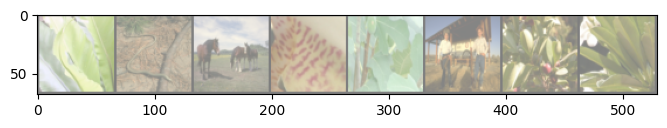

In [30]:
images, labels = next(iter(dataloader))
print('original')
plt.rcParams['figure.figsize'] = (8, 8)
show_image(torchvision.utils.make_grid(images))
plt.show()

In [37]:
# Visulize the data
dataiter = iter(dataloader)
images, labels = dataiter.next()
images = images.view(images.size(0), -1)

#Get one random image
img = images[0]
img = img.view(1, 3, 64, 64)
print('Image shape:', img.shape)

AttributeError: '_SingleProcessDataLoaderIter' object has no attribute 'next'

# Model Architecture

**Encoder layer:**
- Input ->  (64, 64, 3)
- Conv2d (3x3, 32 filters, stride=1, padding=1) + ReLU -> (64, 64, 32)
- MaxPool (2x2) -> (32, 32, 32)
- Conv2d (3x3, 64 filters) + ReLU -> (32, 32, 64)
- MaxPool (2x2) -> (16, 16, 64)
- Conv2d (3x3, 128 filters) + ReLU -> (16, 16, 128)
- MaxPool (2x2) -> (8, 8, 128) => Latent feature map

**Decoder Layer**
- Upsampling (2x2) -> (16, 16, 128)
- Conv2d (3x3, 64 filters) + ReLU -> (16, 16, 64)
- Upsampling (2x2) -> (32, 32, 64)
- Conv2d (3x3, 32 filters) + ReLU -> (32, 32, 32)
- Upsampling (2x2) -> (64, 64, 32)
- Conv2d (3x3. 3 filters, activation = sigmoid) -> (64, 64, 3)

Note:
- Difference between Upsampling and Conv2dTranspose:
    + Upsampling:cheaper upsampling without trainable parameters
    + Conv2dTranspose: want trainable parameters

In [3]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            # Input: 3, 64, 64
            nn.Conv2d(3, 32, kernel_size = 3, padding= 1), # 32, 64, 64
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32, 32, 32
            nn.Conv2d(32, 64, kernel_size = 3, padding= 1), # 64, 32, 32
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64, 16, 16
            nn.Conv2d(64, 128, kernel_size = 3, padding= 1), # 128, 16, 16
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 128, 8, 8
        )
    
    def forward(self, x):
        x = self.encoder(x)
        return x

In [4]:
print(Encoder())

Encoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)


In [5]:
# Decoder class
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        # Decoder
        self.decoder = nn.Sequential(
            # Input: 128, 8, 8
            nn.ConvTranspose2d(128, 64, kernel_size = 2, stride= 2), # 64, 16, 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size = 2, stride= 2), # 32, 32, 32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size = 2, stride= 2), # 3, 64, 64
            nn.Sigmoid() # To ensure the output is between 0 and 1
        )
    
    def forward(self, x):
        x = self.decoder(x)
        return x

In [6]:
print(Decoder())

Decoder(
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)


In [7]:
# Autoencoder class
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
print(AutoEncoder())

AutoEncoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
      (3): ReLU()
      (4): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
      (5): Sigmoid()
    )
  )
)


In [9]:
# TEST MODEL
input = torch.rand((1, 3, 64, 64)) # batch_size, channels, height, width
model = AutoEncoder()
model(input).shape

torch.Size([1, 3, 64, 64])

In [31]:
# TRAINING THE MODEL
model = AutoEncoder()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
num_epochs = 30


In [33]:
for epoch in range(num_epochs):
    losses_epoch = []
    for batch_idx, (data, target) in enumerate(dataloader):
        #data = data.view(-1, 1, 64, 64)
        output = model(data)

        loss = criterion(output, data)
        losses_epoch.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {np.mean(losses_epoch)}") 

Epoch 1/30, Loss: 0.06873829833542307
Epoch 2/30, Loss: 0.05206604340734581
Epoch 3/30, Loss: 0.04199805289196471
Epoch 4/30, Loss: 0.03247732405240337
Epoch 5/30, Loss: 0.025009198191886146
Epoch 6/30, Loss: 0.021155374124646187
Epoch 7/30, Loss: 0.01862516440451145
Epoch 8/30, Loss: 0.017529434020010132
Epoch 9/30, Loss: 0.016566840660137434
Epoch 10/30, Loss: 0.01579355886982133
Epoch 11/30, Loss: 0.014991906238719821
Epoch 12/30, Loss: 0.014509829382101694
Epoch 13/30, Loss: 0.013934675953350961
Epoch 14/30, Loss: 0.01379228534642607
Epoch 15/30, Loss: 0.013563689465324083
Epoch 16/30, Loss: 0.012988896807655692
Epoch 17/30, Loss: 0.01275188821212699
Epoch 18/30, Loss: 0.01293277833610773
Epoch 19/30, Loss: 0.012290875931891302
Epoch 20/30, Loss: 0.012043309126359722
Epoch 21/30, Loss: 0.011709642577140281
Epoch 22/30, Loss: 0.01123324919414396
Epoch 23/30, Loss: 0.010902328901768973
Epoch 24/30, Loss: 0.01008684909902513
Epoch 25/30, Loss: 0.009629097728369137
Epoch 26/30, Loss: 0

In [34]:
def show_image(img):
    img = 0.5 * (img+1) # denormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

original


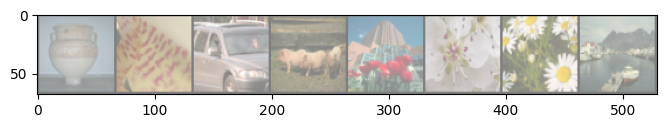

In [35]:
images, labels = next(iter(dataloader))
print('original')
plt.rcParams['figure.figsize'] = (8, 8)
show_image(torchvision.utils.make_grid(images))
plt.show()

In [36]:
print('latent space')
latent_img = model.encoder(images)
print(latent_img.shape)
print('reconstructed image')
reconstructed_img = model.decoder(latent_img)
plt.rcParams['figure.figsize'] = (8, 8)

latent space
torch.Size([8, 128, 8, 8])
reconstructed image


References:
- Notebook AutoEncoder Udacity: https://github.com/udacity/deep-learning-v2-pytorch/blob/master/autoencoder/denoising-autoencoder/Denoising_Autoencoder_Solution.ipynb
- Packtr Pytorch Advanced series